In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq

In [3]:
llm= ChatGroq(model="deepseek-r1-distill-llama-70b")

llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x00000297BC8BF0E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000297BC8BFE00>, model_name='deepseek-r1-distill-llama-70b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [4]:
print(llm.invoke("What is the capital of France?").content)

<think>
Okay, so I need to figure out the capital of France. Hmm, I'm pretty sure I know this, but let me think through it to make sure I'm correct. I remember learning about countries and their capitals in school, but I want to make sure I'm not mixing anything up.

First off, France is a country in Europe, right? It's one of the more well-known countries, so its capital should be a major city. I think the capital is also one of the most famous cities in the world. Let me try to recall any landmarks or events associated with France that might help. Oh, the Eiffel Tower comes to mind. Isn't that in Paris? I'm pretty sure the Eiffel Tower is in Paris, France. So that makes me think Paris is the capital.

Wait, but I also remember something about a city called Lyon in France. Is Lyon the capital? No, I think Lyon is another big city, but not the capital. The capital is usually where the government is, right? So where is the French government located? I believe it's in Paris because that'

In [5]:
print(llm.invoke("What is the capital of india tell me in detail?").content)

<think>
Alright, so I need to figure out the capital of India. Hmm, I think it's New Delhi, but I'm not entirely sure. Let me try to recall what I know about India's geography and political structure.

I remember that India is a country in South Asia, and it's a republic with a parliamentary system. The capital city is where the central government is located. I've heard of cities like Mumbai and Bangalore, but those are more known for business and technology. Then there's Kolkata and Chennai, which are major cities too, but I don't think they're the capital.

Wait, I think the capital is New Delhi. I've heard that before. But I'm not 100% certain. Let me think about other clues. I know that the Prime Minister of India is based in the capital, and I've heard of the Prime Minister's residence being in New Delhi. Also, I believe the President's house is there too, maybe something called Rashtrapati Bhavan.

I also remember that New Delhi is a planned city, different from Old Delhi, which 

In [6]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

In [7]:
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [8]:
search_tool= TavilySearchResults()

In [9]:
search_tool.invoke("What is the capital of France?")

[{'title': 'Paris facts: the capital of France in history',
  'url': 'https://home.adelphi.edu/~ca19535/page%204.html',
  'content': 'page 4\n\n===============\n\nHomeSpainSydneySan FranciscoParisLas VegasMaui\n\n Paris, France\n\nImage 1\n\nParis facts: Paris, the capital of France\n---------------------------------------------\n\nParis is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants).\n\nParis has 2.234 million inhabitants end 2011. She is the core of Ile de France region (12 million people). [...] Before Paris, the capital of France was Lyon (under the Romans). Paris first became the capital of France in 508 under King Clovis. After centuries with no unique capital of France, Paris retrieved its status of capital of France under King Philippe Auguste, who reigned between 1180 and 1223. You can see remains of the Philippe August Paris walls in the passageway between the Louvre parking and Louvre Museum [...] Paris remained the capital

In [10]:
my_code = """
x=10
y=x+10
print(y)
"""

my_code

'\nx=10\ny=x+10\nprint(y)\n'

In [11]:
from langchain_experimental.utilities import PythonREPL

In [12]:
repl= PythonREPL()

In [13]:
repl.run(my_code)

Python REPL can execute arbitrary code. Use with caution.


'20\n'

In [14]:
repl.invoke(my_code) # Getting error because repl is not a tool It's an object of class PythonREPL()

AttributeError: 'PythonREPL' object has no attribute 'invoke'

In [15]:
from langchain_core.tools import tool
# from typing_extensions import Annotated
from typing import Annotated

In [16]:
@tool
def python_repl_tool(code: Annotated[str, "The python code to execute to generate your chart."]):
    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result= repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    # result_str= f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    result_str= f"Successfully executed:\npython\n{code}\nStdout: {result}"
    return result_str

In [17]:
python_repl_tool.invoke(my_code)

'Successfully executed:\npython\n\nx=10\ny=x+10\nprint(y)\n\nStdout: 20\n'

In [18]:
python_repl_tool.invoke("x=10\ny=x+10\nprint(y)")

'Successfully executed:\npython\nx=10\ny=x+10\nprint(y)\nStdout: 20\n'

### WE HAVE TWO SUB AGENT
1. RESEARCHER- internet
2. CODER- executing the code

In [19]:
members= ["researcher", "coder"]

In [20]:
members

['researcher', 'coder']

In [21]:
options= members + ["FINISH"]

In [22]:
options

['researcher', 'coder', 'FINISH']

In [23]:
from typing import Literal
from typing_extensions import TypedDict

### There is no routing logic

it is simply going to return the next candidate (next_agent)<br><br>
this next is containig the next candidate name

In [24]:
class Router(TypedDict):
    next: Literal['researcher', 'coder', 'FINISH']

This is a messagesstate which we are loading from the langgraph (inbuilt message state)

In [25]:
# class MessagesState(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]

In [26]:
from langgraph.graph import StateGraph, MessagesState, START, END

In [27]:
class State(MessagesState):
    next: str

This is how my state will be looking like

In [28]:
state= {"messages": ["hi"], "next": "research_agent"}

state

{'messages': ['hi'], 'next': 'research_agent'}

In [41]:
state1= {"messages": ["Wrte a program of prime number in python"], "next": "coder_agent"}

state1

{'messages': ['Wrte a program of prime number in python'],
 'next': 'coder_agent'}

In [29]:
system_prompt = f""""
You are a supervisor, tasked with managing a conversation between the following workers: {members}. 
Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 
When finished, respond with FINISH.
"""

In [30]:
print(system_prompt)

"
You are a supervisor, tasked with managing a conversation between the following workers: ['researcher', 'coder']. 
Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 
When finished, respond with FINISH.



In [31]:
# system_prompt = f""""
# You are a supervisor, tasked with managing a conversation between the following workers: {members}. 
# Given the following user request, respond with the worker to act next. 
# Each worker will perform a task and respond with their results and status. 
# When finished, respond with FINISH.
# **Strict Guidelines:**
# if there is any common messages like hi, hello, how are you, greetings etc then,respond with FINISH.
# """

In [37]:
messages= [{"role": "system", "content": system_prompt}] + state["messages"]

In [38]:
messages

[{'role': 'system',
  'content': '"\nYou are a supervisor, tasked with managing a conversation between the following workers: [\'researcher\', \'coder\']. \nGiven the following user request, respond with the worker to act next. \nEach worker will perform a task and respond with their results and status. \nWhen finished, respond with FINISH.\n'},
 'hi']

[{'role': 'system',
  'content': '"\nYou are a supervisor, tasked with managing a conversation between the following workers: [\'researcher\', \'coder\']. \nGiven the following user request, respond with the worker to act next. \nEach worker will perform a task and respond with their results and status. \nWhen finished, respond with FINISH.\n'},
 'hi']

In [39]:
llm_with_structure_output= llm.with_structured_output(Router)

In [36]:
llm_with_structure_output.invoke(messages)

{'next': 'researcher'}

In [43]:
messages1= [{"role": "system", "content": system_prompt}] + state1["messages"]

In [44]:
messages1

[{'role': 'system',
  'content': '"\nYou are a supervisor, tasked with managing a conversation between the following workers: [\'researcher\', \'coder\']. \nGiven the following user request, respond with the worker to act next. \nEach worker will perform a task and respond with their results and status. \nWhen finished, respond with FINISH.\n'},
 'Wrte a program of prime number in python']

In [45]:
llm_with_structure_output.invoke(messages1)

{'next': 'coder'}

### you can try out with this prompt also

In [46]:
# system_prompt = f"""
# You are a supervisor managing a task delegation system with the following workers: {members}.

# Your job is to decide which worker should act next based on the user’s input.

# Guidelines:
# - Carefully read the user’s message.
# - If the message clearly requires a specific action (e.g., search, compute, rewrite), assign it to the appropriate worker.
# - If the message is general, conversational, or does **not** require any specific action, immediately respond with `FINISH`.
# - Do **not** invent tasks or assign actions unless the message clearly demands it.

# Each worker will return results after completing their task.
# Once all necessary tasks are completed, end the flow by responding with `FINISH`.

# Be strict — if the message is casual, rhetorical, or lacks a clear task, reply with `FINISH`.
# """

### This is my all three agents

In [47]:
from langgraph.types import Command 

In [48]:
def supervisor_agent(state: State) -> Command[Literal['researcher', 'coder', '__end__']]:
    
    messages= [{"role":"system", "content":system_prompt}] + state["messages"]
    
    llm_with_structure_output= llm.with_structured_output(Router)
    
    response= llm_with_structure_output.invoke(messages)
    
    #this is my response {'next': 'researcher'}
    
    #this is my next worker agent
    goto= response["next"]
    
    print("**********BELOW IS MY GOTO***************")
    
    print(goto)
    
    if goto == "FINISH":
        goto= END
    
    # class State(MessagesState):
    #   next:str
    # output of the state: state={"messages": ["hi"], "next": "researcher"}
    
    return Command(goto=goto, update={"next":goto})

In [49]:
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.prebuilt import create_react_agent

In [ ]:
def research_agent(state: State) -> Command[Literal["supervisor"]]:
    
    research_agent= create_react_agent(llm, tools=[search_tool], prompt="You are a researcher. DO NOT do any math.")
    
    result= research_agent.invoke(state)
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="researcher")
            ]
        },
        goto="supervisor",
    )

In [51]:
def coder_agent(state: State) -> Command[Literal['supervisor']]:

    code_agent= create_react_agent(llm, tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")
    
    result= code_agent.invoke(state)
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder")
            ]
        },
        goto="supervisor",
    )

### This is my orchestration flow with langgraph

In [57]:
graph= StateGraph(State)

In [58]:
graph.add_node("supervisor", supervisor_agent)

In [59]:
graph.add_node("researcher", research_agent)

In [60]:
graph.add_node("coder", coder_agent)

In [61]:
graph.add_edge(START, "supervisor")

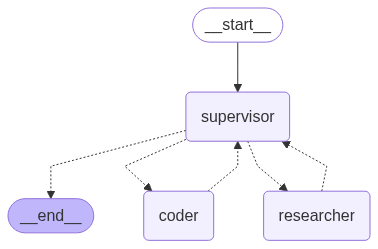

In [62]:
graph.compile()

In [63]:
app= graph.compile()

In [64]:
from IPython.display import Image, display

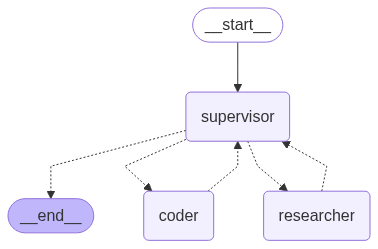

In [65]:
display(Image(app.get_graph().draw_mermaid_png()))

In [67]:
for s in app.stream({"messages": [("user", "What's the square root of 42?")]}, subgraphs=True):
    print(s)
    print("**********BELOW IS MY STATE***************")

**********BELOW IS MY GOTO***************
researcher
((), {'supervisor': {'next': 'researcher'}})
**********BELOW IS MY STATE***************
(('researcher:5e3cf11d-a58b-0a0e-4852-31ac0fe301cd',), {'agent': {'messages': [AIMessage(content='The square root of 42 is approximately 6.48.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 593, 'prompt_tokens': 179, 'total_tokens': 772, 'completion_time': 2.156363636, 'prompt_time': 0.011162556, 'queue_time': 0.056996308999999995, 'total_time': 2.167526192}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--d13fda17-fc93-418e-916c-abc5b873a7d9-0', usage_metadata={'input_tokens': 179, 'output_tokens': 593, 'total_tokens': 772})]}})
**********BELOW IS MY STATE***************
((), {'researcher': {'messages': [HumanMessage(content='The square root of 42 is approximately 6.48.', additional_kwargs={}, response_metadata={}, name='res

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': ''}}

In [ ]:
app.invoke({"messages": [("user", "what is an efficent python code to get prime number?")]}, subgraphs=True)

**********BELOW IS MY GOTO***************
researcher
**********BELOW IS MY GOTO***************
coder
**********BELOW IS MY GOTO***************
coder
**********BELOW IS MY GOTO***************
coder
